<a href="https://colab.research.google.com/github/skarthik1215/ml-project/blob/main/AI_Movie_Recommendation_System_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 AI Movie Recommendation System

**Internship / IP-I Ready — One-Click Google Colab Project**

This notebook is self-contained: the dataset, ML model, visualization and Gradio UI are included. Run the single code cell once.

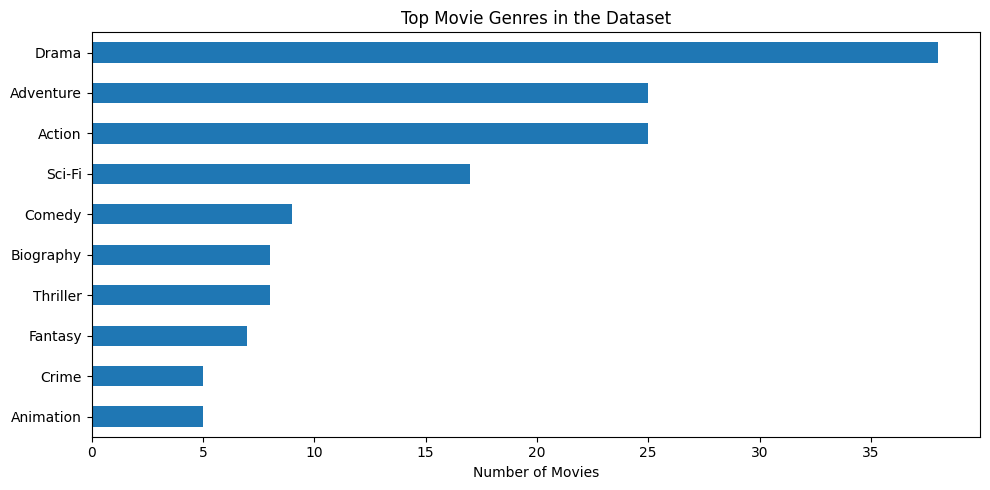

✅ Dataset loaded: 60 movies
✅ TF-IDF features: 1287
✅ Recommendation engine ready!


,Rank,Movie,Genre,Rating,Similarity,Why Recommended
0,1,The Martian,"Adventure, Drama, Sci-Fi",8.0/10,16.5%,Similar themes/genres with 16% content similar...
1,2,Gravity,"Drama, Sci-Fi, Thriller",7.7/10,15.6%,Similar themes/genres with 16% content similar...
2,3,Dune,"Action, Adventure, Drama, Sci-Fi",8.0/10,14.2%,Similar themes/genres with 14% content similar...
3,4,Avengers: Endgame,"Action, Adventure, Sci-Fi",8.4/10,12.1%,Similar themes/genres with 12% content similar...
4,5,Hidden Figures,"Biography, Drama, History",7.8/10,11.1%,Similar themes/genres with 11% content similar...


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://41ef4dec9ee27f993b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:

# ============================================================
# 🎬 AI MOVIE RECOMMENDATION SYSTEM
# Internship / IP-I Ready Project
# TF-IDF + Cosine Similarity + Ratings + Interactive UI
# ============================================================

# Install/import required libraries
!pip -q install gradio scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr

# ------------------------------------------------------------
# 1. SELF-CONTAINED DATASET
# ------------------------------------------------------------
movies = [
("The Shawshank Redemption","Drama",9.3,"Two imprisoned men bond over years and find redemption through acts of common decency.","prison friendship hope redemption drama"),
("The Godfather","Crime, Drama",9.2,"The aging patriarch of an organized crime dynasty transfers control of his clandestine empire to his reluctant son.","crime mafia family power drama"),
("The Dark Knight","Action, Crime, Drama",9.0,"A masked vigilante faces a criminal mastermind who plunges Gotham into chaos.","action superhero crime thriller joker batman"),
("Pulp Fiction","Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangster and his wife intertwine in four tales of violence and redemption.","crime gangster nonlinear violence dark comedy"),
("Inception","Action, Sci-Fi, Thriller",8.8,"A skilled thief who steals secrets through dream-sharing technology is given a chance to erase his past.","science fiction dreams technology action thriller mind"),
("Interstellar","Adventure, Drama, Sci-Fi",8.7,"Explorers travel through a wormhole in space in an attempt to ensure humanity's survival.","space science future adventure gravity astronauts time"),
("The Matrix","Action, Sci-Fi",8.7,"A computer hacker discovers that reality as he knows it is a simulation and joins a rebellion.","science fiction technology virtual reality action hacker"),
("Avengers: Endgame","Action, Adventure, Sci-Fi",8.4,"The Avengers assemble for one final mission to reverse a catastrophic event.","superhero marvel action adventure time travel sci-fi"),
("Iron Man","Action, Adventure, Sci-Fi",7.9,"A billionaire builds a powered suit of armor and becomes a superhero.","superhero marvel technology action engineering"),
("Guardians of the Galaxy","Action, Adventure, Comedy, Sci-Fi",8.0,"A group of unlikely heroes must work together to save the galaxy.","marvel superhero space comedy adventure action"),
("Black Panther","Action, Adventure, Sci-Fi",7.3,"A king returns home to an isolated technologically advanced African nation and faces a challenger.","marvel superhero africa technology action king"),
("Doctor Strange","Action, Adventure, Fantasy",7.5,"A surgeon learns mystical arts after a life-changing accident.","marvel superhero magic fantasy action doctor"),
("Spider-Man: No Way Home","Action, Adventure, Fantasy",8.2,"Spider-Man seeks help from a powerful sorcerer after his identity is revealed.","marvel superhero spider-man multiverse action magic"),
("Thor","Action, Adventure, Fantasy",7.0,"A powerful but arrogant god is cast out of his realm and must learn humility.","marvel superhero fantasy mythology action"),
("Avatar","Action, Adventure, Fantasy, Sci-Fi",7.8,"A marine on an alien moon becomes torn between following orders and protecting a new world.","alien planet adventure science fiction nature action"),
("The Martian","Adventure, Drama, Sci-Fi",8.0,"An astronaut stranded on Mars uses science and ingenuity to survive.","space mars science astronaut survival adventure"),
("Gravity","Drama, Sci-Fi, Thriller",7.7,"Two astronauts struggle to survive after an accident leaves them stranded in orbit.","space astronaut survival science thriller"),
("Arrival","Drama, Sci-Fi, Mystery",7.9,"A linguist works with the military to communicate with mysterious visitors from another world.","alien language science fiction mystery communication"),
("Dune","Action, Adventure, Drama, Sci-Fi",8.0,"A young nobleman becomes involved in a struggle over a valuable desert planet.","space politics adventure science fiction desert"),
("Blade Runner 2049","Drama, Mystery, Sci-Fi",8.0,"A young blade runner uncovers a long-buried secret that leads him to track down a former officer.","science fiction mystery future technology detective"),
("Jurassic Park","Adventure, Sci-Fi, Thriller",8.2,"A theme park suffers a major security breakdown that releases genetically engineered dinosaurs.","dinosaurs science fiction adventure thriller park"),
("Titanic","Drama, Romance",7.9,"A young couple from different social backgrounds meet aboard a famous ill-fated voyage.","romance love ship drama historical"),
("The Lion King","Animation, Adventure, Drama",8.5,"A young lion prince flees his kingdom after tragedy and learns responsibility.","animation family animals adventure king friendship"),
("Toy Story","Animation, Adventure, Comedy",8.3,"A cowboy doll feels threatened when a new spaceman toy arrives.","animation friendship toys family comedy adventure"),
("Finding Nemo","Animation, Adventure, Comedy",8.2,"A clownfish searches the ocean for his missing son with help from a forgetful fish.","animation ocean family adventure friendship comedy"),
("Coco","Animation, Adventure, Family",8.4,"A young musician enters the Land of the Dead to discover his family's musical history.","animation music family adventure mexico fantasy"),
("Up","Animation, Adventure, Comedy",8.3,"An elderly widower travels to South America with a young scout and an unexpected passenger.","animation adventure friendship family comedy"),
("The Social Network","Biography, Drama",7.8,"The founding of a major social networking website and the conflicts that followed.","technology programming startup business friendship drama"),
("The Imitation Game","Biography, Drama, Thriller",8.0,"A mathematician and cryptanalyst works to break an enemy code during wartime.","mathematics technology code science history thriller"),
("Moneyball","Biography, Drama, Sport",7.6,"A baseball manager uses data and statistics to build a competitive team.","data analytics statistics sports business strategy"),
("Ford v Ferrari","Action, Biography, Drama",8.1,"Engineers and drivers build a race car to challenge a dominant competitor.","engineering racing cars competition technology action"),
("Top Gun: Maverick","Action, Drama",8.2,"A veteran pilot trains a new generation of elite aviators for a dangerous mission.","aviation pilot action training friendship adventure"),
("Mission: Impossible - Fallout","Action, Adventure, Thriller",7.7,"An agent and his team race against time after a mission goes wrong.","spy action thriller mission adventure"),
("John Wick","Action, Crime, Thriller",7.4,"A retired assassin returns to his violent past after a personal loss.","action assassin crime revenge thriller"),
("Mad Max: Fury Road","Action, Adventure, Sci-Fi",8.1,"A woman rebels against a tyrant and joins a group fleeing across a wasteland.","action survival dystopia adventure science fiction"),
("The Prestige","Drama, Mystery, Sci-Fi",8.5,"Two rival magicians engage in a dangerous competition involving secrets and technology.","magic mystery rivalry science technology drama"),
("Whiplash","Drama, Music",8.5,"A young drummer enters a demanding music conservatory under an intimidating instructor.","music ambition drama education competition"),
("La La Land","Comedy, Drama, Music, Romance",8.0,"A musician and an aspiring actress pursue their dreams while falling in love.","music romance dreams ambition hollywood"),
("The Pursuit of Happyness","Biography, Drama",8.0,"A struggling salesman fights to build a better future for himself and his son.","family motivation career business success drama"),
("Forrest Gump","Drama, Romance",8.8,"A kind-hearted man witnesses and participates in major events while remaining devoted to his childhood love.","drama romance friendship history motivation"),
("Gladiator","Action, Adventure, Drama",8.5,"A betrayed Roman general seeks revenge after losing his family and position.","action history revenge warrior empire drama"),
("The Lord of the Rings: The Fellowship of the Ring","Action, Adventure, Drama",8.8,"A hobbit begins a journey to destroy a powerful ring and protect Middle-earth.","fantasy adventure friendship magic war hero"),
("Harry Potter and the Sorcerer's Stone","Adventure, Fantasy",7.6,"A young wizard begins his education and discovers a dangerous connection to his past.","fantasy magic school friendship adventure wizard"),
("Pirates of the Caribbean","Action, Adventure, Fantasy",8.0,"A pirate and a young sailor join forces to rescue a kidnapped woman and recover a cursed ship.","pirate adventure fantasy action treasure"),
("The Hunger Games","Action, Adventure, Sci-Fi",7.2,"A young woman volunteers for a deadly televised competition in a dystopian society.","dystopia survival action rebellion science fiction"),
("The Notebook","Drama, Romance",7.8,"An enduring love story follows two people whose relationship survives social pressure and time.","romance love relationship drama emotional"),
("A Beautiful Mind","Biography, Drama",8.2,"A brilliant mathematician struggles with personal challenges while pursuing groundbreaking ideas.","mathematics science genius drama psychology"),
("Hidden Figures","Biography, Drama, History",7.8,"Three mathematicians make major contributions to a space program while overcoming barriers.","mathematics nasa space science women history"),
("The Terminal","Comedy, Drama, Romance",7.4,"A traveler becomes stranded in an airport and builds a life while waiting for a resolution.","airport travel comedy friendship romance"),
("Zindagi Na Milegi Dobara","Comedy, Drama, Adventure",8.2,"Three friends take a road trip that changes their perspectives on life and friendship.","friendship travel adventure comedy life"),
("3 Idiots","Comedy, Drama",8.4,"Three engineering students navigate friendship, pressure and education.","college engineering friendship education comedy motivation"),
("Drishyam","Crime, Drama, Thriller",8.2,"A family man uses careful planning to protect his family after a crisis.","crime family mystery thriller planning"),
("Baahubali: The Beginning","Action, Drama",8.0,"A young man discovers his royal heritage and becomes involved in a battle for a kingdom.","india action kingdom warrior family adventure"),
("RRR","Action, Drama",7.8,"Two revolutionaries form a powerful friendship while fighting against colonial rule.","india action friendship revolution history"),
("Jawan","Action, Thriller",7.0,"A man driven by a personal mission confronts corruption and injustice.","india action revenge justice thriller"),
("Dangal","Biography, Drama, Sport",8.3,"A father trains his daughters to become successful wrestlers despite social expectations.","india sports family motivation wrestling"),
("Lagaan","Drama, Sport, Musical",8.1,"Villagers challenge colonial rulers to a cricket match to avoid an unfair tax.","india cricket history sports friendship music"),
("Kantara","Action, Drama, Mystery",8.6,"A conflict between tradition, land and power unfolds in a rural community.","india folklore action mystery culture tradition"),
("PK","Comedy, Drama, Fantasy",8.1,"An unusual visitor questions human beliefs and social customs while searching for answers.","india comedy fantasy society alien friendship"),
("Taare Zameen Par","Drama, Family",8.3,"A teacher helps a child who struggles with school and learning discover his strengths.","india education family motivation teacher student"),
]

movies = pd.DataFrame(movies, columns=["title","genre","rating","description","tags"])

# ------------------------------------------------------------
# 2. FEATURE ENGINEERING
# ------------------------------------------------------------
movies["content"] = movies["genre"] + " " + movies["description"] + " " + movies["tags"]

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform(movies["content"])
similarity_matrix = cosine_similarity(tfidf_matrix)

# ------------------------------------------------------------
# 3. RECOMMENDATION ENGINE
# ------------------------------------------------------------
def recommend_movies(movie_name, top_n=5, genre_filter="All", min_rating=0.0):
    if not movie_name or movie_name.strip() == "":
        return pd.DataFrame(columns=["Rank","Movie","Genre","Rating","Similarity","Why Recommended"])

    matches = movies[movies["title"].str.lower() == movie_name.strip().lower()]
    if matches.empty:
        # Fuzzy-ish partial title fallback
        matches = movies[movies["title"].str.lower().str.contains(movie_name.strip().lower(), regex=False)]
    if matches.empty:
        return pd.DataFrame([{
            "Rank": "",
            "Movie": "Movie not found",
            "Genre": "Try selecting a movie from the dropdown",
            "Rating": "",
            "Similarity": "",
            "Why Recommended": ""
        }])

    idx = matches.index[0]
    scores = similarity_matrix[idx]
    candidates = []

    for i, score in enumerate(scores):
        if i == idx:
            continue
        if movies.loc[i, "rating"] < float(min_rating):
            continue
        if genre_filter != "All" and genre_filter.lower() not in movies.loc[i, "genre"].lower():
            continue

        # Combine content similarity and rating quality
        final_score = (0.80 * float(score)) + (0.20 * (movies.loc[i, "rating"] / 10.0))
        candidates.append((i, score, final_score))

    candidates.sort(key=lambda x: x[2], reverse=True)

    rows = []
    for rank, (i, sim, final_score) in enumerate(candidates[:int(top_n)], 1):
        rows.append({
            "Rank": rank,
            "Movie": movies.loc[i, "title"],
            "Genre": movies.loc[i, "genre"],
            "Rating": f"{movies.loc[i, 'rating']:.1f}/10",
            "Similarity": f"{sim*100:.1f}%",
            "Why Recommended": f"Similar themes/genres with {sim*100:.0f}% content similarity."
        })
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 4. MOVIE DETAILS
# ------------------------------------------------------------
def movie_details(movie_name):
    if not movie_name:
        return "### Select a movie\nChoose a movie from the dropdown."
    row = movies[movies["title"] == movie_name]
    if row.empty:
        return "Movie not found."
    r = row.iloc[0]
    return f"""### 🎬 {r['title']}
**⭐ Rating:** {r['rating']}/10

**🎭 Genre:** {r['genre']}

**📝 Plot:** {r['description']}

**🔎 AI Features:** {r['tags']}
"""

# ------------------------------------------------------------
# 5. DATASET / VISUALIZATION
# ------------------------------------------------------------
genre_counts = {}
for g in movies["genre"]:
    for part in g.split(", "):
        genre_counts[part] = genre_counts.get(part, 0) + 1

top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_genres.sort_values().plot(kind="barh")
plt.title("Top Movie Genres in the Dataset")
plt.xlabel("Number of Movies")
plt.tight_layout()
plt.show()

print(f"✅ Dataset loaded: {len(movies)} movies")
print(f"✅ TF-IDF features: {tfidf_matrix.shape[1]}")
print("✅ Recommendation engine ready!")

# ------------------------------------------------------------
# 6. INTERACTIVE GRADIO UI
# ------------------------------------------------------------
movie_choices = movies["title"].tolist()
genre_choices = ["All"] + sorted(genre_counts.keys())

with gr.Blocks(title="AI Movie Recommendation System") as demo:
    gr.Markdown("""
    # 🎬 AI Movie Recommendation System
    ### TF-IDF + Cosine Similarity + Rating-Based Ranking
    **Internship / IP-I Project**

    Select a movie and the AI engine will recommend movies with similar
    themes, genres and descriptions.
    """)

    with gr.Row():
        movie_dropdown = gr.Dropdown(
            choices=movie_choices,
            value="Interstellar",
            label="🎥 Select Movie",
            allow_custom_value=True
        )
        genre_dropdown = gr.Dropdown(
            choices=genre_choices,
            value="All",
            label="🎭 Genre Filter"
        )
        rating_slider = gr.Slider(
            minimum=0, maximum=9.5, value=0,
            step=0.1, label="⭐ Minimum Rating"
        )
        count_slider = gr.Slider(
            minimum=3, maximum=10, value=5,
            step=1, label="🔢 Recommendations"
        )

    recommend_btn = gr.Button("🚀 Get AI Recommendations", variant="primary")

    details = gr.Markdown(movie_details("Interstellar"))

    results = gr.Dataframe(
        headers=["Rank","Movie","Genre","Rating","Similarity","Why Recommended"],
        label="🤖 AI Recommendations",
        interactive=False
    )

    gr.Markdown("""
    ---
    ### 🧠 How the AI works
    1. Movie descriptions, genres and tags are converted into **TF-IDF vectors**.
    2. **Cosine similarity** measures how similar two movies are.
    3. The system combines content similarity with movie rating.
    4. The highest-scoring movies are returned as recommendations.

    ### 📌 Technologies
    `Python` • `Pandas` • `Scikit-learn` • `TF-IDF` • `Cosine Similarity` • `Gradio` • `Matplotlib`
    """)

    movie_dropdown.change(movie_details, movie_dropdown, details)
    recommend_btn.click(
        recommend_movies,
        inputs=[movie_dropdown, count_slider, genre_dropdown, rating_slider],
        outputs=results
    )

# Automatically generate first result
initial = recommend_movies("Interstellar", 5, "All", 0)
display(initial)

# Launch UI
demo.launch(share=True)
